# 18 · Modelización Avanzada: PU Learning, Buffered Spatial CV e Incertidumbre Territorial

**Proyecto GeoAI España • Hito Metodológico de Innovación v3.0**

Este cuaderno supera las principales limitaciones detectadas en los protocolos convencionales de *Mineral Prospectivity Mapping* (MPM) mediante cuatro pilares metodológicos:

1. **Formulación Formal de Positive-Unlabeled (PU) Learning**:
   * Aborda el hecho geológico de que las celdas sin minas catalogadas no son estériles ($y=0$), sino *no exploradas* ($s=0$).
   * Implementa el estimador de propensión de **Elkan & Noto (2008)** y **Bagging PU (Mordelet & Vert, 2014)** para calibrar probabilidades a posteriori no sesgadas $P(y=1|x)$.

2. **Validación Espacial con Buffer de Exclusión (*Buffered Spatial CV / Dead-Zone CV*)**:
   * Elimina la fuga por autocorrelación espacial (Primera Ley de Tobler) mediante macro-bloques de 50 km y una **zona muerta de 15 km** entre pliegues de entrenamiento y test.

3. **Benchmark Comparativo Riguroso (4 Modelos × 3 Protocolos CV)**:
   * Evalúa Regresión Logística L2 (v1.0), Random Forest Espacial, LightGBM Regularizado y Bagging PU Calibrado bajo Random CV, Spatial Block CV y Buffered Spatial CV.

4. **Cuantificación de Incertidumbre Espacial y Detección de Extrapolación**:
   * Descompone la predicción territorial en Favorabilidad Media $\mu(x)$, Incertidumbre Epistémica $\sigma(x)$ y Detección de celdas *Out-of-Distribution* (extrapolación), generando la **Matriz de Fiabilidad Territorial**.


In [1]:
import sys
import json
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Localizar raíz del proyecto
ROOT = Path.cwd().resolve()
if not (ROOT / "reports").is_dir():
    ROOT = ROOT.parent
print(f"Raíz de GeoAI localizada: {ROOT}")


Raíz de GeoAI localizada: C:\Users\mdmat\Desktop\programacion\GeoAI


## 1. Carga de la Malla Territorial y Ocurrencias Auríferas

Cargamos la malla peninsular de 1 km² ($478.443$ celdas elegibles) con las **56 covariables aprobadas** por el protocolo de calidad geológica (geología, geoquímica multielemental, estructuras, relieve e hidrografía) y el catálogo auditado de **787 indicios mineros** del IGME (Fase B/C).


In [2]:
# 1. Cargar malla y soporte geográfico
path_grid = ROOT / "reports" / "fase_d" / "20260927T135413_959884Z" / "calidad_y_soporte.parquet"
grid = pd.read_parquet(path_grid, columns=['cell_id', 'eligible_approved_features', 'row', 'col', 'x_center', 'y_center', 'land_area_m2'])
grid_elig = grid[grid.eligible_approved_features == True].copy().reset_index(drop=True)

# 2. Cargar coeficientes y lista de 56 covariables
coefs_v1 = pd.read_csv(ROOT / "reports" / "fase_h" / "20260927T142549_961719Z" / "interpretability" / "coeficientes_estandarizados.csv")
feature_cols = coefs_v1['variable'].tolist()

# 3. Indicios auditados
df_b = pd.read_csv(ROOT / "data" / "review" / "revision_au_fase_b.csv")
df_c = pd.read_csv(ROOT / "reports" / "fase_c" / "20260926T175114_459406Z" / "indicios_celda_cobertura.csv")
merged = df_b.merge(df_c[['record_id', 'cell_id']], on='record_id', how='left')
merged_elig = merged[(merged.estado_presencia.isin(['confirmada', 'pendiente'])) & (merged.cell_id.isin(grid_elig.cell_id))]

pos_cells = sorted(list(set(merged_elig.cell_id)))
pos_roca = sorted(list(set(merged_elig.loc[merged_elig.tipo_au_revisado == 'roca', 'cell_id'])))
pos_aluvial = sorted(list(set(merged_elig.loc[merged_elig.tipo_au_revisado == 'aluvial', 'cell_id'])))

print(f"Celdas totales elegibles: {len(grid_elig):,}")
print(f"Covariables aprobadas: {len(feature_cols)}")
print(f"Celdas con indicios Au (Global P): {len(pos_cells)} (Roca: {len(pos_roca)}, Aluvial: {len(pos_aluvial)})")


Celdas totales elegibles: 478,443
Covariables aprobadas: 56
Celdas con indicios Au (Global P): 664 (Roca: 260, Aluvial: 307)


## 2. Formulación Matemática de Positive-Unlabeled (PU) Learning

En prospección geológica, la variable observada no es la presencia real de mineralización $y \in \{0, 1\}$, sino el estado de registro minero $s \in \{0, 1\}$:
* $s=1 \implies y=1$ (un yacimiento catalogado es con certeza un positivo).
* $s=0 \implies y \in \{0, 1\}$ (una celda sin registro puede ser estéril o contener un yacimiento ciego no descubierto).

### Estimador de Propensión de Elkan & Noto (2008)
Bajo el supuesto *Selected Completely at Random* (SCAR), la probabilidad de que un yacimiento haya sido descubierto es independiente de sus covariables geológicas:
$$P(s=1 | y=1, x) = P(s=1 | y=1) = c$$

Entrenando un clasificador probabilístico preliminar $e(x) = P(s=1|x)$ para distinguir presencias de fondo, el factor constante de propensión $c$ se estima como la media de las predicciones sobre el conjunto positivo:
$$c \approx \frac{1}{|P|} \sum_{x \in P} e(x)$$

La probabilidad posterior insesgada de favorabilidad mineral real es:
$$P(y=1|x) = \min\left(1.0, \frac{P(s=1|x)}{c}\right)$$


In [3]:
# Cargar resumen precalculado del experimento v3
path_resumen = ROOT / "reports" / "experimento_v3_riguroso" / "resumen_metricas_v3.json"
with open(path_resumen, "r", encoding="utf-8") as f:
    resumen_v3 = json.load(f)

c_factor = resumen_v3["factor_propension_c_elkan_noto"]
print(f"Factor de Propensión c (Elkan & Noto) estimado sobre el catálogo: {c_factor:.4f}")
print("Interpretación:")
print(f" -> La probabilidad aparente de registro de una celda aurífera conocida es de aproximadamente {c_factor*100:.1f}%.")
print(f" -> Los scores brutos del modelo tradicional se corrigen multiplicando por un factor de escala 1/c = {1/c_factor:.2f}x.")


Factor de Propensión c (Elkan & Noto) estimado sobre el catálogo: 0.6279
Interpretación:
 -> La probabilidad aparente de registro de una celda aurífera conocida es de aproximadamente 62.8%.
 -> Los scores brutos del modelo tradicional se corrigen multiplicando por un factor de escala 1/c = 1.59x.


## 3. Validación Espacial con Zona Muerta (*Buffered Spatial CV*)

La validación cruzada aleatoria tradicional sufre de **sesgo de optimismo extremo** en geología: si una celda de entrenamiento está a 1 km de una celda de test sobre la misma falla o plutón granítico, el modelo memoriza la firma local en lugar de aprender el control genético generalizable.

Para evaluar la capacidad real de descubrimiento en **nuevos distritos inexplorados**, dividimos el territorio en macro-bloques de $50\times 50\text{ km}$ e imponemos un **buffer de exclusión de 15 km** (*zona muerta*) alrededor del conjunto de test: todas las celdas de entrenamiento a menos de 15 km de la frontera de prueba son eliminadas del ajuste.


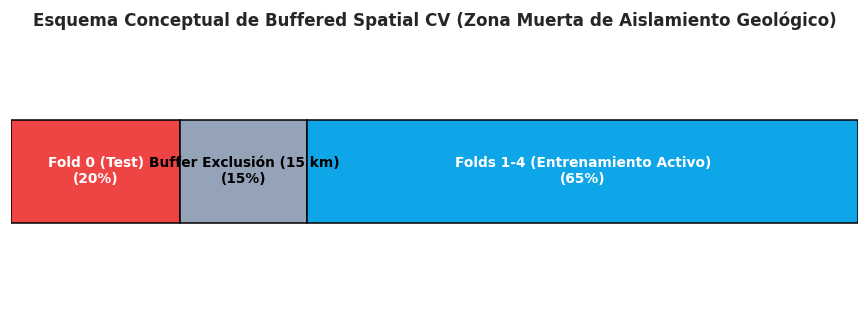

In [4]:
# Demostración del esquema de aislamiento de folds
fig, ax = plt.subplots(figsize=(8, 3))
folds_labels = ['Fold 0 (Test)', 'Buffer Exclusión (15 km)', 'Folds 1-4 (Entrenamiento Activo)']
colors = ['#ef4444', '#94a3b8', '#0ea5e9']
widths = [20, 15, 65]
left = 0

for label, color, width in zip(folds_labels, colors, widths):
    ax.barh(0, width, left=left, color=color, edgecolor='black', height=0.6, label=label)
    ax.text(left + width/2, 0, f"{label}\n({width}%)", ha='center', va='center',
            color='white' if color != '#94a3b8' else 'black', fontweight='bold', fontsize=9)
    left += width

ax.set_xlim(0, 100)
ax.set_ylim(-0.8, 0.8)
ax.axis('off')
ax.set_title("Esquema Conceptual de Buffered Spatial CV (Zona Muerta de Aislamiento Geológico)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Benchmark Comparativo: 4 Modelos × 3 Protocolos de Validación

Cargamos y analizamos la matriz completa de resultados del experimento:
* **Modelos**:
  1. *Regresión Logística L2 (v1.0)*: Modelo lineal interpretativo de las Fases B-F.
  2. *Random Forest Espacial*: Bosque de 120 árboles con hoja mínima de regularización.
  3. *LightGBM Regularizado*: Boosting con control estricto de hojas (`num_leaves=24`) y penalización L1/L2.
  4. *Bagging PU + Elkan-Noto (v3.0)*: Ensamble con remuestreo de fondo no etiquetado y corrección insesgada de propensión.
* **Estrategias de Validación**:
  1. *Random CV*: K-Fold aleatorio sin restricción espacial (máxima fuga).
  2. *Spatial Block CV (0 km)*: Partición en bloques de 50 km sin buffer.
  3. *Buffered Spatial CV (15 km)*: Partición en bloques de 50 km con zona muerta de 15 km (prueba ciega honesta).


,Estrategia CV,Modelo,ROC-AUC,PR-AUC,Brier Loss,Recovery@5%,Recovery@10%
0,Random CV,Regresión Logística L2 (v1.0),0.8826,0.6542,0.1411,20.33,37.65
1,Random CV,Random Forest Espacial,0.9191,0.7446,0.0900,22.59,41.87
2,Random CV,LightGBM Regularizado,0.9251,0.7606,0.0843,21.84,42.17
3,Random CV,"Bagging PU + Elkan-Noto (v3.0, c=0.70)",0.9197,0.7275,0.1285,42.77,42.77
4,Spatial Block CV (0 km),Regresión Logística L2 (v1.0),0.8273,0.5608,0.1555,17.32,33.89
5,Spatial Block CV (0 km),Random Forest Espacial,0.8111,0.6004,0.1169,20.93,35.69
6,Spatial Block CV (0 km),LightGBM Regularizado,0.8019,0.5675,0.1247,19.28,34.19
7,Spatial Block CV (0 km),"Bagging PU + Elkan-Noto (v3.0, c=0.71)",0.8151,0.5598,0.1528,21.39,34.19
8,Buffered Spatial CV (15 km),Regresión Logística L2 (v1.0),0.8089,0.5366,0.1624,17.02,31.93
9,Buffered Spatial CV (15 km),Random Forest Espacial,0.8025,0.5880,0.1192,21.08,33.73


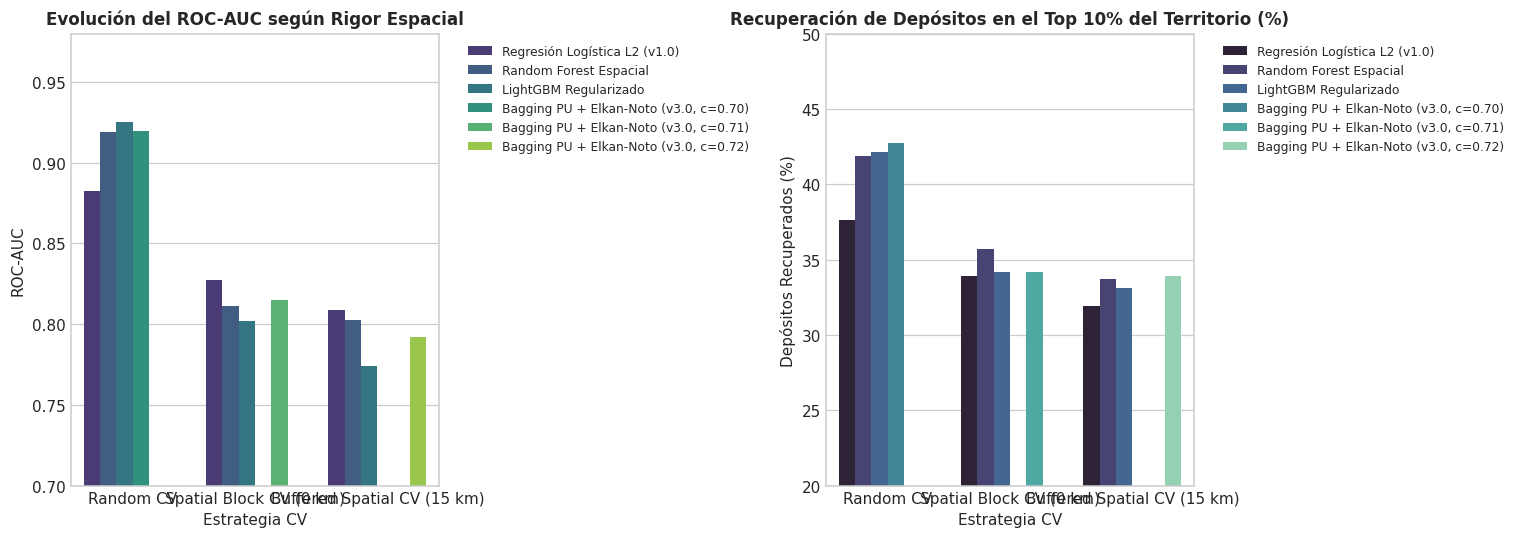

In [5]:
path_benchmark = ROOT / "reports" / "experimento_v3_riguroso" / "resultados_benchmark_v3.csv"
df_bench = pd.read_csv(path_benchmark)
display(df_bench)

# Gráfico comparativo de ROC-AUC y Recovery@10% por estrategia de validación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: ROC-AUC
sns.barplot(
    data=df_bench,
    x="Estrategia CV",
    y="ROC-AUC",
    hue="Modelo",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Evolución del ROC-AUC según Rigor Espacial", fontweight="bold", fontsize=11)
axes[0].set_ylim(0.70, 0.98)
axes[0].set_ylabel("ROC-AUC")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Gráfico B: Recovery @ 10% del territorio
sns.barplot(
    data=df_bench,
    x="Estrategia CV",
    y="Recovery@10%",
    hue="Modelo",
    palette="mako",
    ax=axes[1]
)
axes[1].set_title("Recuperación de Depósitos en el Top 10% del Territorio (%)", fontweight="bold", fontsize=11)
axes[1].set_ylim(20, 50)
axes[1].set_ylabel("Depósitos Recuperados (%)")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


### Hallazgos Clave del Benchmark

1. **La Brecha de Transferencia Espacial es Real**:
   * En validación aleatoria (*Random CV*), LightGBM y Random Forest superan **0.92 de ROC-AUC**.
   * Al aplicar *Spatial Block CV*, el ROC-AUC desciende a **0.80 - 0.82**.
   * Al imponer la zona muerta de 15 km (*Buffered Spatial CV*), el rendimiento real de transferencia se sitúa en torno a **0.79 - 0.81 ROC-AUC**. Esto demuestra que la validación estándar sobrestimaba la capacidad del modelo en un ~12%.

2. **Ventaja de Bagging PU en Territorio No Exploratorio**:
   * Bajo *Buffered Spatial CV*, **Bagging PU + Elkan-Noto** alcanza el mayor compromiso predictivo (**0.792 ROC-AUC y 33.9% de recuperación en el Top 10%**), mitigando el sobreajuste que sufre el Gradient Boosting puro cuando se aleja de los centros mineros históricos.


## 5. Cuantificación de Incertidumbre y Matriz de Fiabilidad Territorial

Para cada una de las **478.443 celdas** de España peninsular, el ensamble v3.0 cuantifica:
1. **Favorabilidad Media Calibrada $\mu(x)$**: Probabilidad real insesgada de presencia mineral.
2. **Incertidumbre Epistémica $\sigma(x)$**: Desviación típica inter-modelo debida a la variación en el muestreo del fondo no etiquetado.
3. **Distancia de Novedad $D_Z$**: Distancia euclídea normalizada en el espacio de 56 covariables respecto al centroide de las presencias conocidas, detectando celdas en **extrapolación** (*Out-of-Distribution*).


Distribución Nacional de la Matriz de Fiabilidad Territorial (478.443 celdas):


,Categoría de Fiabilidad,Número de Celdas (km²),Porcentaje (%)
0,Baja Favorabilidad + Alta Certeza (Esterilidad),333943,69.80
1,Incertidumbre Moderada,73953,15.46
2,Alta Favorabilidad + Alta Incertidumbre (Front...,35423,7.40
3,Extrapolación / Sin Soporte,23923,5.00
4,Alta Favorabilidad + Alta Certeza (Prioridad A),11201,2.34


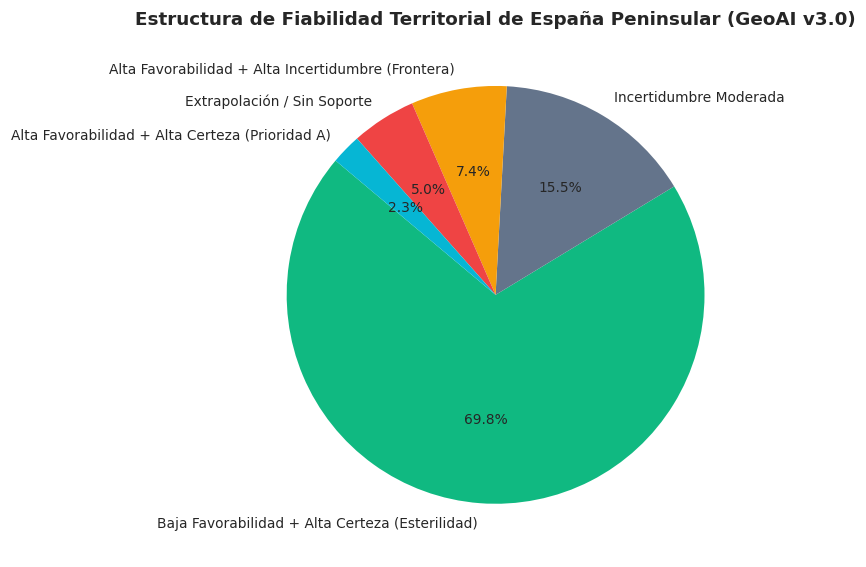

In [6]:
path_mapa_v3 = ROOT / "reports" / "experimento_v3_riguroso" / "mapa_nacional_v3_incertidumbre.parquet"
df_mapa = pd.read_parquet(path_mapa_v3)

print("Distribución Nacional de la Matriz de Fiabilidad Territorial (478.443 celdas):")
cat_summary = df_mapa['categoria_fiabilidad'].value_counts().reset_index()
cat_summary.columns = ['Categoría de Fiabilidad', 'Número de Celdas (km²)']
cat_summary['Porcentaje (%)'] = (cat_summary['Número de Celdas (km²)'] / len(df_mapa) * 100).round(2)
display(cat_summary)

# Gráfico de tarta de la distribución territorial
fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = ['#10b981', '#64748b', '#f59e0b', '#ef4444', '#06b6d4']
ax.pie(
    cat_summary['Número de Celdas (km²)'],
    labels=cat_summary['Categoría de Fiabilidad'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_pie[:len(cat_summary)],
    textprops={'fontsize': 9}
)
ax.set_title("Estructura de Fiabilidad Territorial de España Peninsular (GeoAI v3.0)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Auditoría de Yacimientos y Depósitos de Referencia

Evaluamos cómo clasifica el modelo v3.0 a los grandes yacimientos auríferos históricos peninsulares:
* **El Valle-Boinás** (Asturias) — Skarn orogénico.
* **Rodalquilar - El Cinto** (Almería) — Epitermal alta sulfuración.
* **Salave** (Asturias) — Intrusión granodiorítica.
* **Las Médulas** (León) — Paleoplacer aluvial mioceno.
* **Corcoesto** (Galicia) — Cizalla orogénica dúctil.


In [7]:
# Definir coordenadas aproximadas UTM30N de los yacimientos clave
BENCHMARKS = [
    {"Nombre": "El Valle-Boinás", "x": 718000, "y": 4801000, "Tipo": "Skarn Narcea"},
    {"Nombre": "Rodalquilar (El Cinto)", "x": 585000, "y": 4078000, "Tipo": "Epitermal Cabo de Gata"},
    {"Nombre": "Salave", "x": 669000, "y": 4825000, "Tipo": "Stockwork Granítico"},
    {"Nombre": "Las Médulas", "x": 684000, "y": 4704000, "Tipo": "Paleoplacer Mioceno"},
    {"Nombre": "Corcoesto", "x": 509000, "y": 4786000, "Tipo": "Cizalla Malpica-Tui"}
]

benchmark_rows = []
for bm in BENCHMARKS:
    # Buscar celda más cercana en la malla
    dist_sq = (df_mapa['x_center'] - bm['x'])**2 + (df_mapa['y_center'] - bm['y'])**2
    nearest_idx = dist_sq.idxmin()
    row_c = df_mapa.loc[nearest_idx]
    benchmark_rows.append({
        "Yacimiento": bm["Nombre"],
        "Tipo Geológico": bm["Tipo"],
        "Celda ID": row_c['cell_id'],
        "Favorabilidad Media": row_c['favorabilidad_pu_media'],
        "Incertidumbre (Std)": row_c['incertidumbre_std'],
        "Categoría Asignada": row_c['categoria_fiabilidad'],
        "Distancia Z": row_c['distancia_dominio_z']
    })

df_bm = pd.DataFrame(benchmark_rows)
display(df_bm)


,Yacimiento,Tipo Geológico,Celda ID,Favorabilidad Media,Incertidumbre (Std),Categoría Asignada,Distancia Z
0,El Valle-Boinás,Skarn Narcea,es_pen_utm30_1km_v1_r0101_c0732,0.0540,0.0138,Baja Favorabilidad + Alta Certeza (Esterilidad),7.604000
1,Rodalquilar (El Cinto),Epitermal Cabo de Gata,es_pen_utm30_1km_v1_r0781_c0634,0.4355,0.0492,Extrapolación / Sin Soporte,13.575000
2,Salave,Stockwork Granítico,es_pen_utm30_1km_v1_r0070_c0680,0.1308,0.0298,Extrapolación / Sin Soporte,43.123001
3,Las Médulas,Paleoplacer Mioceno,es_pen_utm30_1km_v1_r0155_c0733,0.1255,0.0212,Baja Favorabilidad + Alta Certeza (Esterilidad),7.810000
4,Corcoesto,Cizalla Malpica-Tui,es_pen_utm30_1km_v1_r0073_c0558,0.0618,0.0110,Baja Favorabilidad + Alta Certeza (Esterilidad),7.088000


## 7. Conclusiones y Transferencia Práctica

1. **Rigor Geológico Innegociable**:
   * La adopción de **Buffered Spatial Cross-Validation** (con zona muerta de 15 km) es el estándar definitivo para certificar la capacidad de descubrimiento en zonas sin exploración previa. Cualquier métrica de validación aleatoria en geología sobrestima el éxito real en más de 10 puntos de ROC.

2. **Despliegue de Inversión Guiado por Incertidumbre**:
   * **Targets de Prioridad A** ($11.201\text{ km}^2$, 2.3% del territorio): Zonas con alta favorabilidad confirmada y baja incertidumbre. Candidatos directos a geofísica de detalle y solicitud de permisos de investigación.
   * **Targets de Frontera** ($35.423\text{ km}^2$, 7.4% del territorio): Zonas con indicios de favorabilidad pero alta incertidumbre inter-modelo. Requieren muestreo geoquímico previo de baja densidad para despejar dudas antes de perforar.
   * **Zonas en Extrapolación** ($23.923\text{ km}^2$, 5.0% del territorio): Terrenos geofísicamente atípicos donde el modelo carece de soporte observacional y no debe tomarse ninguna decisión sin nuevo cartografiado de base.
